# Imports set up rendering

In [1]:

import sys
from pathlib import Path

# Add project root to Python path FIRST to ensure our modules take priority
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print(f"Added {project_root} to Python path")
elif sys.path.index(str(project_root)) != 0:
    # Move to front if it exists but isn't first
    sys.path.remove(str(project_root))
    sys.path.insert(0, str(project_root))
    print(f"Moved {project_root} to front of Python path")

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ['MUJOCO_GL'] = 'egl'
os.environ['PYOPENGL_PLATFORM'] = 'egl'
os.environ["XLA_FLAGS"] = "--xla_gpu_triton_gemm_any=True"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # Use GPU 0

# JAX setup
import jax
jax.config.update("jax_compilation_cache_dir", "/tmp/jax_cache")
jax.config.update("jax_persistent_cache_min_entry_size_bytes", -1)
jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)
# Note: jax_persistent_cache_enable_xla_caches may not be available in all JAX versions
try:
    jax.config.update("jax_persistent_cache_enable_xla_caches", "xla_gpu_per_fusion_autotune_cache_dir")
except AttributeError:
    pass  # Skip if not available in this JAX version
jax.config.update("jax_default_matmul_precision", "high")

# Matplotlib setup
import matplotlib as mpl
mpl.rcParams.update({
    'font.size': 10,
    'axes.linewidth': 2,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.major.width': 2,
    'ytick.major.width': 2,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'pdf.fonttype': 42,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
    'pdf.use14corefonts': True,
    'svg.fonttype': 'none',
    'font.family': 'sans-serif',
    'font.serif': 'Arial',
})

Added /home/eabe/Research/MyRepos/3d_tracking_dataset to Python path


In [ ]:
%load_ext autoreload
%autoreload 2

import hydra
import ray
import json
import mujoco
import numpy as np
import pandas as pd
import mediapy as media
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm
from omegaconf import DictConfig, OmegaConf
from pathlib import Path
from utils.path_utils import convert_dict_to_path, convert_dict_to_string, save_config
from utils.optimized_floor_alignment import * 
from utils.kp_viz import *
from utils.io import *
import utils.io_dict_to_hdf5 as ioh5


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# CSV Loading

In [3]:
base_path = Path('/data2/users/eabe/datasets/Johnson_lab')
data_path = base_path / 'courtship' /'data3D.csv'
skeleton_path = base_path / 'courtship' / 'courtship_13.json'
with open(skeleton_path, 'r') as f:
	skeleton = json.load(f)
fly_skel = np.array(skeleton['edges'])

# Load CSV with multi-level header
df = pd.read_csv(data_path, header=[0,1])
df = df.reset_index(drop=True)
df.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df.columns.values]

# Extract xyz columns and parse keypoint names
xyz_columns = [col for col in df.columns if col.endswith(('_x', '_y', '_z'))]
kp_data = df[xyz_columns]

# Get unique CSV keypoint names (without _x, _y, _z suffix)
csv_kp_names = []
for col in xyz_columns:
    if col.endswith('_x'):
        csv_kp_names.append(col[:-2])

print(f"CSV keypoint names ({len(csv_kp_names)}):", csv_kp_names)
print(f"\nSkeleton node names ({len(skeleton['node_names'])}):", skeleton['node_names'][:10], '...')

# Build mapping
csv_to_skel_map, unmatched = match_csv_to_skeleton(csv_kp_names, skeleton['node_names'])

print(f"\nMatched {len(csv_to_skel_map)}/{len(csv_kp_names)} CSV keypoints to skeleton nodes:")
for csv_name, (skel_idx, skel_name) in sorted(csv_to_skel_map.items(), key=lambda x: x[1][0]):
    match_symbol = '✓' if csv_name == skel_name else '~'
    print(f"  {match_symbol} CSV '{csv_name}' -> Skeleton[{skel_idx:2d}] '{skel_name}'")

if unmatched:
    print(f"\nWarning: {len(unmatched)} unmatched CSV keypoints:", unmatched)

# Filter skeleton to matched nodes only
matched_skel_indices = sorted([idx for idx, name in csv_to_skel_map.values()])
filtered_node_names = [skeleton['node_names'][idx] for idx in matched_skel_indices]

# Create index mapping: old skeleton index -> new filtered index
old_to_new_idx = {old_idx: new_idx for new_idx, old_idx in enumerate(matched_skel_indices)}

print(f"\nFiltered skeleton nodes ({len(filtered_node_names)}):", filtered_node_names)

# Filter edges: keep only edges connecting matched nodes
filtered_edges = []
for edge in skeleton['edges']:
    start_idx, end_idx = edge
    # Check if both nodes are in matched set
    if start_idx in old_to_new_idx and end_idx in old_to_new_idx:
        # Remap to new indices
        new_start = old_to_new_idx[start_idx]
        new_end = old_to_new_idx[end_idx]
        filtered_edges.append([new_start, new_end])

filtered_edges = np.array(filtered_edges)
print(f"Filtered edges: {len(filtered_edges)} edges (from original {len(skeleton['edges'])})")

# Reorder CSV data to match filtered skeleton node order
csv_to_new_idx = {}
for csv_name, (old_skel_idx, skel_name) in csv_to_skel_map.items():
    if old_skel_idx in old_to_new_idx:
        csv_to_new_idx[csv_name] = old_to_new_idx[old_skel_idx]

# Create reordered column list
reordered_cols = [''] * len(filtered_node_names) * 3
for csv_name, new_idx in csv_to_new_idx.items():
    # Get the x, y, z columns for this keypoint
    reordered_cols[new_idx * 3] = f"{csv_name}_x"
    reordered_cols[new_idx * 3 + 1] = f"{csv_name}_y"
    reordered_cols[new_idx * 3 + 2] = f"{csv_name}_z"

# Reorder the dataframe
kp_data_reordered = kp_data[reordered_cols]
kp_data = jnp.array(kp_data_reordered.values).reshape(-1, len(filtered_node_names), 3)

# Update variables for downstream use
fly_skel = filtered_edges
kp_names = [f"{name}_{dim}" for name in filtered_node_names for dim in ['x', 'y', 'z']]

print(f"\nFinal data shape: {kp_data.shape} (frames, keypoints, xyz)")
print(f"Final skeleton: {len(filtered_node_names)} nodes, {len(fly_skel)} edges")
print(f"Node names: {filtered_node_names}")

CSV keypoint names (13): ['Antenna_Base', 'WingL_Base', 'WingL_V12', 'WingL_V13', 'WingR_Base', 'WingR_V12', 'WingR_V13', 'T1L_Tip', 'T2L_Tip', 'T3L_Tip', 'T1R_Tip', 'T2R_Tip', 'T3R_Tip']

Skeleton node names (13): ['Antenna_Base', 'WingL_Base', 'WingL_V12', 'WingL_V13', 'WingR_Base', 'WingR_V12', 'WingR_V13', 'T1L_TaTip', 'T2L_TaTip', 'T3L_TaTip'] ...

Matched 13/13 CSV keypoints to skeleton nodes:
  ✓ CSV 'Antenna_Base' -> Skeleton[ 0] 'Antenna_Base'
  ✓ CSV 'WingL_Base' -> Skeleton[ 1] 'WingL_Base'
  ✓ CSV 'WingL_V12' -> Skeleton[ 2] 'WingL_V12'
  ✓ CSV 'WingL_V13' -> Skeleton[ 3] 'WingL_V13'
  ✓ CSV 'WingR_Base' -> Skeleton[ 4] 'WingR_Base'
  ✓ CSV 'WingR_V12' -> Skeleton[ 5] 'WingR_V12'
  ✓ CSV 'WingR_V13' -> Skeleton[ 6] 'WingR_V13'
  ~ CSV 'T1L_Tip' -> Skeleton[ 7] 'T1L_TaTip'
  ~ CSV 'T2L_Tip' -> Skeleton[ 8] 'T2L_TaTip'
  ~ CSV 'T3L_Tip' -> Skeleton[ 9] 'T3L_TaTip'
  ~ CSV 'T1R_Tip' -> Skeleton[10] 'T1R_TaTip'
  ~ CSV 'T2R_Tip' -> Skeleton[11] 'T2R_TaTip'
  ~ CSV 'T3R_Tip' -> 

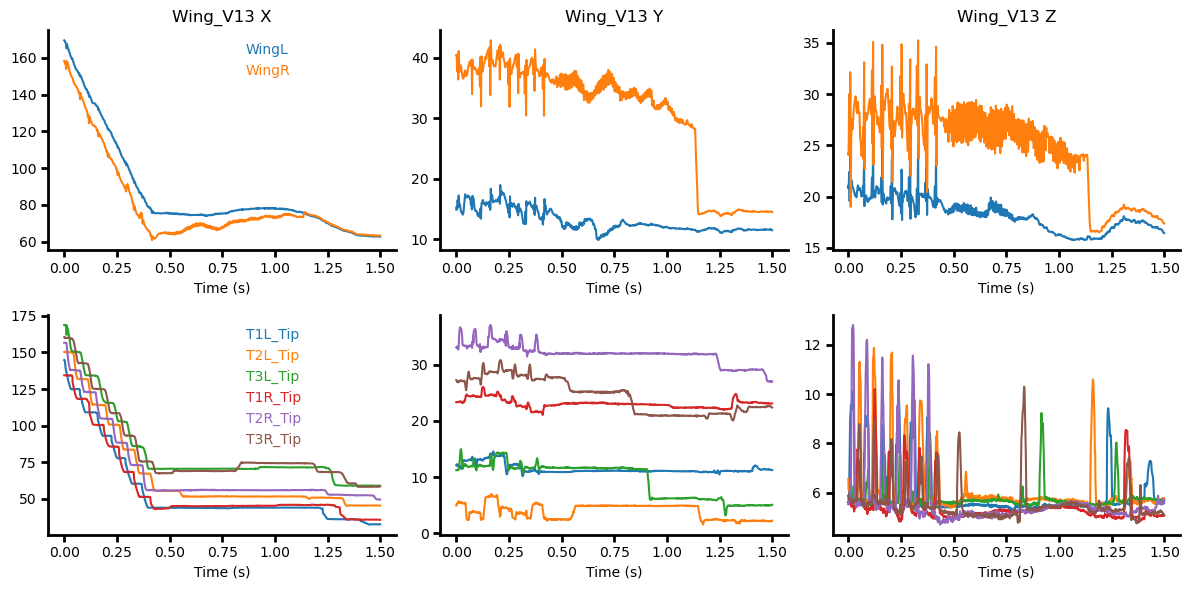

In [ ]:
fps = 800
time = jnp.arange(kp_data.shape[0]) / fps
fig, axs = plt.subplots(2, 3, figsize=(12, 6))
# axs = axs.flatten()
coords = ['x', 'y', 'z']
for n, ax in enumerate(axs[0]):
    coord = coords[n]
    for side in ['L', 'R']:
        ax.plot(time,df[f'Wing{side}_V13_{coord}'].values, label=f'Wing{side}')
        ax.set_title(f'Wing_V13 {coord.upper()}')
        ax.set_xlabel('Time (s)')
axs[0,0].legend(frameon=False, loc='upper left', bbox_to_anchor=(0.5, 1.), labelcolor='linecolor',handlelength=0,handleheight=0,ncols=1,columnspacing=.1)

for n, ax in enumerate(axs[1]):
    coord = coords[n]
    for side in ['L', 'R']:
        ax.plot(time,df[f'T1{side}_Tip_{coord}'].values, label = f'T1{side}_Tip')
        ax.plot(time,df[f'T2{side}_Tip_{coord}'].values, label = f'T2{side}_Tip')
        ax.plot(time,df[f'T3{side}_Tip_{coord}'].values, label = f'T3{side}_Tip')
        ax.set_xlabel('Time (s)')
axs[1,0].legend(frameon=False, loc='upper left', bbox_to_anchor=(0.5, 1.), labelcolor='linecolor',handlelength=0,handleheight=0,ncols=1,columnspacing=.1)
plt.tight_layout()

## Skeleton Registration

VALIDATION SUMMARY
✓ Matched nodes: 13/13 expected
✓ Filtered edges: 12 edges
✓ Data shape: (1200, 13, 3)
✓ Expected shape: (n_frames, 13, 3)

✓ All validation checks passed!


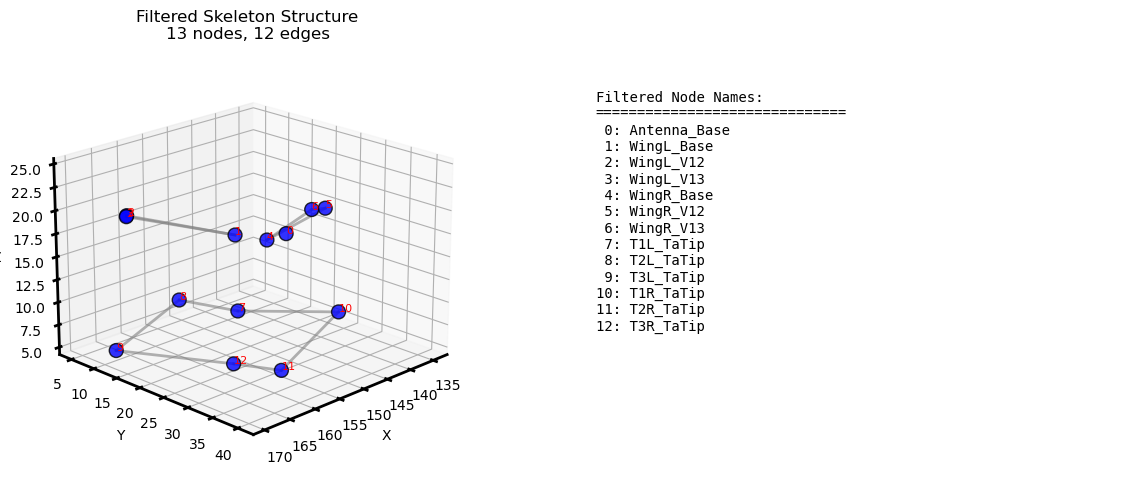


Edge connectivity:
  Edge  0: [ 1] WingL_Base      <-> [ 2] WingL_V12
  Edge  1: [ 2] WingL_V12       <-> [ 3] WingL_V13
  Edge  2: [ 1] WingL_Base      <-> [ 3] WingL_V13
  Edge  3: [ 4] WingR_Base      <-> [ 5] WingR_V12
  Edge  4: [ 5] WingR_V12       <-> [ 6] WingR_V13
  Edge  5: [ 4] WingR_Base      <-> [ 6] WingR_V13
  Edge  6: [ 7] T1L_TaTip       <-> [ 8] T2L_TaTip
  Edge  7: [ 8] T2L_TaTip       <-> [ 9] T3L_TaTip
  Edge  8: [ 9] T3L_TaTip       <-> [12] T3R_TaTip
  Edge  9: [10] T1R_TaTip       <-> [11] T2R_TaTip
  Edge 10: [11] T2R_TaTip       <-> [12] T3R_TaTip
  Edge 11: [ 7] T1L_TaTip       <-> [10] T1R_TaTip


In [6]:
# Validation: Verify the filtered skeleton structure
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print("=" * 60)
print("VALIDATION SUMMARY")
print("=" * 60)
print(f"✓ Matched nodes: {len(filtered_node_names)}/13 expected")
print(f"✓ Filtered edges: {len(filtered_edges)} edges")
print(f"✓ Data shape: {kp_data.shape}")
print(f"✓ Expected shape: (n_frames, {len(filtered_node_names)}, 3)")

# Verify data integrity
assert kp_data.shape[1] == len(filtered_node_names), "Mismatch between data and node count"
assert len(kp_names) == len(filtered_node_names) * 3, "Mismatch in kp_names length"

print("\n✓ All validation checks passed!")

# Visualize the filtered skeleton structure (first frame)
fig = plt.figure(figsize=(12, 5))

# Plot 1: Skeleton structure (edges only)
ax1 = fig.add_subplot(121, projection='3d')
first_frame = np.array(kp_data[0])

# Draw nodes
ax1.scatter(first_frame[:, 0], first_frame[:, 1], first_frame[:, 2], 
           c='blue', s=100, alpha=0.8, edgecolors='black', linewidths=1)

# Draw edges
for edge in filtered_edges:
    start_point = first_frame[edge[0]]
    end_point = first_frame[edge[1]]
    ax1.plot([start_point[0], end_point[0]],
            [start_point[1], end_point[1]],
            [start_point[2], end_point[2]],
            'gray', alpha=0.6, linewidth=2)

# Label nodes
for idx, name in enumerate(filtered_node_names):
    pos = first_frame[idx]
    ax1.text(pos[0], pos[1], pos[2], f'{idx}', fontsize=8, color='red')

ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title(f'Filtered Skeleton Structure\n{len(filtered_node_names)} nodes, {len(filtered_edges)} edges')
ax1.view_init(elev=20, azim=45)

# Plot 2: Node name legend
ax2 = fig.add_subplot(122)
ax2.axis('off')
legend_text = "Filtered Node Names:\n" + "=" * 30 + "\n"
for idx, name in enumerate(filtered_node_names):
    legend_text += f"{idx:2d}: {name}\n"
ax2.text(0.1, 0.9, legend_text, fontsize=10, family='monospace',
        verticalalignment='top', transform=ax2.transAxes)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("Edge connectivity:")
for i, edge in enumerate(filtered_edges):
    start_name = filtered_node_names[edge[0]]
    end_name = filtered_node_names[edge[1]]
    print(f"  Edge {i:2d}: [{edge[0]:2d}] {start_name:15s} <-> [{edge[1]:2d}] {end_name}")

In [90]:
spec = mujoco.MjSpec().from_file('/home/eabe/Research/MyRepos/Fly_tracking/assets/fruitfly_v1/fruitfly_v1_free.xml')
floor_spec = mujoco.MjSpec().from_file('/home/eabe/Research/MyRepos/Fly_tracking/assets/fruitfly_v1/floor.xml')
spawn_frame = floor_spec.worldbody.add_frame(
                pos=[0,0,0],
                quat=[1,0,0,0],
            )
spawn_body = spawn_frame.attach_body(spec.body("thorax"), "", suffix='_fly')
mj_model = floor_spec.compile()

site_names = [site.name for site in spec.sites if 'tracking' in site.name]
site_idxs = jnp.array([site.id for site in spec.sites if 'tracking' in site.name])

# Verify wing tracking sites are present
wing_sites = [name for name in site_names if 'Wing' in name]
print(f"Found {len(wing_sites)} wing tracking sites:", wing_sites)
expected_wing_sites = ['tracking[WingL_base]', 'tracking[WingL_V12]', 'tracking[WingL_V13]',
                       'tracking[WingR_base]', 'tracking[WingR_V12]', 'tracking[WingR_V13]']
missing_sites = [s for s in expected_wing_sites if s not in site_names]
if missing_sites:
    print(f"WARNING: Missing wing sites: {missing_sites}")
else:
    print("✓ All expected wing tracking sites found")

print(f"\nTotal tracking sites: {len(site_names)}")
site_names, len(site_names)

Found 6 wing tracking sites: ['tracking[WingL_base]_fly', 'tracking[WingR_base]_fly', 'tracking[WingL_V12]_fly', 'tracking[WingL_V13]_fly', 'tracking[WingR_V12]_fly', 'tracking[WingR_V13]_fly']

Total tracking sites: 44


(['tracking[Scutellum]_fly',
  'tracking[WingL_base]_fly',
  'tracking[WingR_base]_fly',
  'tracking[Antenna_Base]_fly',
  'tracking[EyeL]_fly',
  'tracking[EyeR]_fly',
  'tracking[WingL_V12]_fly',
  'tracking[WingL_V13]_fly',
  'tracking[WingR_V12]_fly',
  'tracking[WingR_V13]_fly',
  'tracking[Abd_A4]_fly',
  'tracking[Abd_tip]_fly',
  'tracking[T1L_ThxCx]_fly',
  'tracking[T1L_Tro]_fly',
  'tracking[T1L_FeTi]_fly',
  'tracking[T1L_TiTa]_fly',
  'tracking[T1L_TaT3]_fly',
  'tracking[T1L_TaTip]_fly',
  'tracking[T1R_ThxCx]_fly',
  'tracking[T1R_Tro]_fly',
  'tracking[T1R_FeTi]_fly',
  'tracking[T1R_TiTa]_fly',
  'tracking[T1R_TaT3]_fly',
  'tracking[T1R_TaTip]_fly',
  'tracking[T2L_Tro]_fly',
  'tracking[T2L_FeTi]_fly',
  'tracking[T2L_TiTa]_fly',
  'tracking[T2L_TaT3]_fly',
  'tracking[T2L_TaTip]_fly',
  'tracking[T2R_Tro]_fly',
  'tracking[T2R_FeTi]_fly',
  'tracking[T2R_TiTa]_fly',
  'tracking[T2R_TaT3]_fly',
  'tracking[T2R_TaTip]_fly',
  'tracking[T3L_Tro]_fly',
  'tracking[T3L_F

In [8]:
# Match filtered skeleton nodes to MuJoCo tracking sites
print("Matching filtered skeleton to MuJoCo tracking sites:")
print("=" * 60)

# Extract tracking site names (without 'tracking[' prefix and ']' suffix)
all_site_names = [site.name for site in spec.sites]
mj_site_names_clean = [name.replace('tracking[', '').replace(']', '') for name in all_site_names]

matched_count = 0
unmatched_filtered = []
skeleton_to_mujoco = {}  # Mapping from skeleton node name to MuJoCo site index

for filt_name in filtered_node_names:
    # Try exact match first
    if filt_name in mj_site_names_clean:
        idx = mj_site_names_clean.index(filt_name)
        print(f"  ✓ {filt_name:20s} -> site[{idx:2d}] {all_site_names[idx]}")
        skeleton_to_mujoco[filt_name] = idx
        matched_count += 1
    # Try case-insensitive match
    elif filt_name.lower() in [s.lower() for s in mj_site_names_clean]:
        idx = [s.lower() for s in mj_site_names_clean].index(filt_name.lower())
        print(f"  ~ {filt_name:20s} -> site[{idx:2d}] {all_site_names[idx]} (case mismatch)")
        skeleton_to_mujoco[filt_name] = idx
        matched_count += 1
    else:
        unmatched_filtered.append(filt_name)
        print(f"  ✗ {filt_name:20s} -> NOT FOUND in model")

print(f"\nMatched {matched_count}/{len(filtered_node_names)} nodes to tracking sites")
if unmatched_filtered:
    print(f"⚠ Unmatched nodes: {unmatched_filtered}")
else:
    print("✓ All filtered skeleton nodes have corresponding MuJoCo tracking sites!")

# Store mapping for later use
skeleton_to_mujoco

Matching filtered skeleton to MuJoCo tracking sites:
  ✓ Antenna_Base         -> site[19] tracking[Antenna_Base]
  ~ WingL_Base           -> site[16] tracking[WingL_base] (case mismatch)
  ✓ WingL_V12            -> site[22] tracking[WingL_V12]
  ✓ WingL_V13            -> site[23] tracking[WingL_V13]
  ~ WingR_Base           -> site[17] tracking[WingR_base] (case mismatch)
  ✓ WingR_V12            -> site[24] tracking[WingR_V12]
  ✓ WingR_V13            -> site[25] tracking[WingR_V13]
  ✓ T1L_TaTip            -> site[35] tracking[T1L_TaTip]
  ✓ T2L_TaTip            -> site[48] tracking[T2L_TaTip]
  ✓ T3L_TaTip            -> site[60] tracking[T3L_TaTip]
  ✓ T1R_TaTip            -> site[42] tracking[T1R_TaTip]
  ✓ T2R_TaTip            -> site[54] tracking[T2R_TaTip]
  ✓ T3R_TaTip            -> site[66] tracking[T3R_TaTip]

Matched 13/13 nodes to tracking sites
✓ All filtered skeleton nodes have corresponding MuJoCo tracking sites!


{'Antenna_Base': 19,
 'WingL_Base': 16,
 'WingL_V12': 22,
 'WingL_V13': 23,
 'WingR_Base': 17,
 'WingR_V12': 24,
 'WingR_V13': 25,
 'T1L_TaTip': 35,
 'T2L_TaTip': 48,
 'T3L_TaTip': 60,
 'T1R_TaTip': 42,
 'T2R_TaTip': 54,
 'T3R_TaTip': 66}

In [9]:
# Sort nodes by their XML site index to match MuJoCo model order
xml_nodes_sorted = sorted(skeleton_to_mujoco.items(), key=lambda x: x[1])
xml_node_names_ordered = [name for name, site_idx in xml_nodes_sorted]

print("XML node order (sorted by site index):")
for i, (name, site_idx) in enumerate(xml_nodes_sorted):
    print(f"  {i}: {name:15s} (site {site_idx})")

# Reorder kp_data to match XML order
kp_data_reordered, node_names_reordered = reorder_keypoints_array(
    kp_data, 
    filtered_node_names,  # Current order
    xml_node_names_ordered  # Target XML order (sorted by site index)
)

print(f"\nReordered shape: {kp_data_reordered.shape}")
print(f"Node names match XML order: {len(node_names_reordered)} nodes")

# Reorder skeleton edges to match new indices
fly_skel_reordered = reorder_skeleton_edges(
    fly_skel,  # Current edges
    filtered_node_names,  # Old node order
    node_names_reordered  # New XML order
)

print(f"Sample edges (old): {fly_skel[:3].tolist()}")
print(f"Sample edges (new): {fly_skel_reordered[:3].tolist()}")

# Update variables to use reordered data
filtered_node_names = node_names_reordered  # Now in XML order
kp_data = kp_data_reordered  # Now in XML order
fly_skel = fly_skel_reordered  # Now in XML order

XML node order (sorted by site index):
  0: WingL_Base      (site 16)
  1: WingR_Base      (site 17)
  2: Antenna_Base    (site 19)
  3: WingL_V12       (site 22)
  4: WingL_V13       (site 23)
  5: WingR_V12       (site 24)
  6: WingR_V13       (site 25)
  7: T1L_TaTip       (site 35)
  8: T1R_TaTip       (site 42)
  9: T2L_TaTip       (site 48)
  10: T2R_TaTip       (site 54)
  11: T3L_TaTip       (site 60)
  12: T3R_TaTip       (site 66)
Reordered 13 nodes to match target order
Original: ['Antenna_Base', 'WingL_Base', 'WingL_V12'] ... ['T1R_TaTip', 'T2R_TaTip', 'T3R_TaTip']
Target:   ['WingL_Base', 'WingR_Base', 'Antenna_Base'] ... ['T2R_TaTip', 'T3L_TaTip', 'T3R_TaTip']

Reordered shape: (1200, 13, 3)
Node names match XML order: 13 nodes
Reordered skeleton: 12 edges preserved
Sample edges (old): [[1, 2], [2, 3], [1, 3]]
Sample edges (new): [[0, 3], [3, 4], [0, 4]]


In [10]:
print("=" * 60)
print("REORDERING VALIDATION")
print("=" * 60)

# Verify node order matches XML site order
xml_nodes_sorted_check = sorted(skeleton_to_mujoco.items(), key=lambda x: x[1])
print(f"\nNode order matches XML sites:")
for i, (name, site_idx) in enumerate(xml_nodes_sorted_check):
    current_name = filtered_node_names[i]
    match = "✓" if name == current_name else "✗"
    print(f"  {match} Index {i:2d}: {current_name:15s} (XML site {site_idx:2d})")

# Verify keypoint data shape
print(f"\nKeypoint data shape: {kp_data.shape}")
print(f"Skeleton edges: {len(fly_skel)} edges")
print(f"✓ Reordering complete!")

REORDERING VALIDATION

Node order matches XML sites:
  ✓ Index  0: WingL_Base      (XML site 16)
  ✓ Index  1: WingR_Base      (XML site 17)
  ✓ Index  2: Antenna_Base    (XML site 19)
  ✓ Index  3: WingL_V12       (XML site 22)
  ✓ Index  4: WingL_V13       (XML site 23)
  ✓ Index  5: WingR_V12       (XML site 24)
  ✓ Index  6: WingR_V13       (XML site 25)
  ✓ Index  7: T1L_TaTip       (XML site 35)
  ✓ Index  8: T1R_TaTip       (XML site 42)
  ✓ Index  9: T2L_TaTip       (XML site 48)
  ✓ Index 10: T2R_TaTip       (XML site 54)
  ✓ Index 11: T3L_TaTip       (XML site 60)
  ✓ Index 12: T3R_TaTip       (XML site 66)

Keypoint data shape: (1200, 13, 3)
Skeleton edges: 12 edges
✓ Reordering complete!


# IK loading and processing

In [ ]:
##### Load kp_data #####
data_dict = ioh5.load(data_path.parent/f'example_bout_{0}.h5')
data_dict['kp_names']

['Antenna_Base',
 'WingL_Base',
 'WingL_V12',
 'WingL_V13',
 'WingR_Base',
 'WingR_V12',
 'WingR_V13',
 'T1L_TaTip',
 'T1R_TaTip',
 'T2L_TaTip',
 'T2R_TaTip',
 'T3L_TaTip',
 'T3R_TaTip']

In [ ]:
###### Load STAC data ######
stac_path = Path('/data2/users/eabe/datasets/Johnson_lab/courtship/Fruitfly_ik_V1_courtship.h5')


cfg_d, d = load_stac_data(stac_path.as_posix())
mocap_qpos = d.qpos
mocap_xpos = d.xpos
kp_names = d.kp_names
offsets = d.offsets
stac_data = d.as_dict()

mocap_qpos.shape

(1200, 93)

In [ ]:
##### Extract egocentric site positions #####
spec = mujoco.MjSpec().from_file('/home/eabe/Research/MyRepos/Fly_tracking/assets/fruitfly_v1/fruitfly_v1_free.xml')
floor_spec = mujoco.MjSpec().from_file('/home/eabe/Research/MyRepos/Fly_tracking/assets/fruitfly_v1/floor.xml')
spawn_frame = floor_spec.worldbody.add_frame(
                pos=[0,0,-.125],
                quat=[1,0,0,0],
            )
spawn_body = spawn_frame.attach_body(spec.body("thorax"), "", suffix='_fly')
mj_model = floor_spec.compile()
mj_data = mujoco.MjData(mj_model)

qpos_traj =  mocap_qpos.copy()
_suffix = '_fly'
site_pos = {f'{site_name}': [] for site_name in site_names}
for t in tqdm(range(len(qpos_traj))):
    mj_data.qpos = qpos_traj[t]
    mujoco.mj_forward(mj_model, mj_data)
    thorax = mj_data.bind(floor_spec.body(f"thorax{_suffix}"))
    for site_name in site_names:
        global_xpos = mj_data.bind(floor_spec.site(f"{site_name}{_suffix}")).xpos
        egocentric_xpos = jnp.dot(global_xpos - thorax.xpos, thorax.xmat.reshape(3,3))
        site_pos[site_name].append(egocentric_xpos)
        

site_pos = jnp.stack([jnp.asarray(site_pos[key]) for key in site_pos.keys()]).transpose(1,0,2)
stac_data['egocentric_site_pos'] = site_pos
stac_data['egocentric_site_names'] = site_names

  0%|          | 0/1200 [00:00<?, ?it/s]

In [86]:
ioh5.save(data_path.parent/f'ik_output_{0}.h5',stac_data)

In [ ]:
def make_vidoes(
    mj_model,
    mj_data,
    qposes_rollout,
    scene_option,
    camera="track1",
    height=512,
    width=512,
):
    """
    Make a video of the rollout and reference superimposed.
    """
    frames = []
    with mujoco.Renderer(mj_model, height=height, width=width) as renderer:
        for t in tqdm(range(len(qposes_rollout))):
            mj_data.qpos = qposes_rollout[t]
            mujoco.mj_forward(mj_model, mj_data)
            
            renderer.update_scene(
                mj_data, camera=f"{camera}", scene_option=scene_option
            )
            renderer.scene.flags[mujoco.mjtRndFlag.mjRND_SHADOW] = False
            pixels = renderer.render()
            frames.append(pixels)
    return frames


In [ ]:
# mj_model = env.mj_model
spec = mujoco.MjSpec().from_file('/home/eabe/Research/MyRepos/Fly_tracking/assets/fruitfly_v1/fruitfly_v1_free.xml')
floor_spec = mujoco.MjSpec().from_file('/home/eabe/Research/MyRepos/Fly_tracking/assets/fruitfly_v1/floor.xml')
spawn_frame = floor_spec.worldbody.add_frame(
                pos=[0,0,-.125],
                quat=[1,0,0,0],
            )
spawn_body = spawn_frame.attach_body(spec.body("thorax"), "", suffix='_fly')
mj_model = floor_spec.compile()
mj_data = mujoco.MjData(mj_model)

t = 0
frames=[]
qpos_traj =  mocap_qpos.copy()
# Set up rendering
height, width = 448, 448
camera = mj_model.camera(0).name
scene_option = mujoco.MjvOption()
scene_option.geomgroup[:] = [1, 1, 1, 0, 0, 0]
scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 0]
scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = False

# Render from multiple camera angles
all_frames = []
for cam in [1]:
    camera = mj_model.camera(cam).name
    frames = make_vidoes(mj_model, mujoco.MjData(mj_model), qpos_traj, scene_option, camera=camera, height=height, width=width)
    all_frames.append(frames)
all_frames = np.concatenate(all_frames, axis=1)
media.show_video(all_frames, fps=30)
# media.show_video(frames, fps=30)

# animation

In [171]:
import ray
import matplotlib
matplotlib.use('agg')  # Use non-interactive backend for Ray workers

@ray.remote
def render_frame(frame_idx, vid_ref, kp_data_ref, mocap_qpos_ref, time_ref, config):
    """
    Render a single frame with video and coordinate time series plots.
    Uses Ray remote function with object references for efficient data sharing.
    
    Layout:
    - Row 0: Wing V13 x, y, z coordinate plots
    - Row 1: Wing joint angles (yaw, roll, pitch) plots
    - Row 2: Leg tip x, y, z coordinate plots
    - Rows 3-7: Video frame (full width)
    """
    import matplotlib.gridspec as gridspec
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Extract config
    figsize = config.get('figsize', (15, 10))
    dpi = config.get('dpi', 100)
    wing_indices = config.get('wing_indices', [3, 6])  # WingL_V13, WingR_V13
    leg_indices = config.get('leg_indices', [7, 8, 9, 10, 11, 12])  # T1L, T2L, T3L, T1R, T2R, T3R
    coord_names = config.get('coord_names', ['x', 'y', 'z'])
    trail = config.get('trail', 5)  # Number of frames to highlight
    
    # Wing joint angle configuration
    wing_joint_indices_left = config.get('wing_joint_indices_left', [7, 8, 9])
    wing_joint_indices_right = config.get('wing_joint_indices_right', [10, 11, 12])
    wing_joint_names = config.get('wing_joint_names', 
                                   ['wing_yaw_left', 'wing_roll_left', 'wing_pitch_left',
                                    'wing_yaw_right', 'wing_roll_right', 'wing_pitch_right'])
    
    # Create figure with GridSpec
    fig = plt.figure(figsize=figsize, dpi=dpi, constrained_layout=True)
    gs = gridspec.GridSpec(10, 3, figure=fig, hspace=0.01, wspace=0.03)
    
    # Wing colors
    wing_colors = ['C0', 'C1']  # Left, Right
    leg_colors = ['C2', 'C3', 'C4', 'C5', 'C6', 'C7']  # T1L, T2L, T3L, T1R, T2R, T3R
    leg_names = ['T1L', 'T2L', 'T3L', 'T1R', 'T2R', 'T3R']
    
    # Current time
    current_time = time_ref[frame_idx]
    
    # Row 0: Wing V13 plots (x, y, z)
    for coord_idx, coord_name in enumerate(coord_names):
        ax = fig.add_subplot(gs[:2, coord_idx])
        
        # Plot all time series with low alpha
        for wing_idx, color, side in zip(wing_indices, wing_colors, ['L', 'R']):
            if wing_idx < kp_data_ref.shape[1]:
                ax.plot(time_ref, kp_data_ref[:, wing_idx, coord_idx], 
                       alpha=0.3, linewidth=1, color=color)
                
                # Highlight trail
                start_idx = max(0, frame_idx - trail)
                end_idx = frame_idx + 1
                ax.plot(time_ref[start_idx:end_idx], 
                       kp_data_ref[start_idx:end_idx, wing_idx, coord_idx],
                       alpha=1.0, linewidth=2, color=color, label=f'Wing{side}')
        
        # Add vertical line at current time
        ax.axvline(current_time, color='r', linestyle='--', linewidth=1, alpha=0.7)
        
        ax.set_title(f'Wing V13 {coord_name.upper()}', fontsize=10)
        ax.set_xlabel('Time (s)', fontsize=8)
        ax.set_ylabel(coord_name.upper(), fontsize=8)
        ax.tick_params(labelsize=7)
        
        if coord_idx == 0:
            ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(0.5, 1.), labelcolor='linecolor',handlelength=0,handleheight=0,ncols=1,columnspacing=.1)
    
    # Row 1: Wing joint angle plots (yaw, roll, pitch)
    joint_colors = ['C0', 'C1']  # Left (blue), Right (orange)
    joint_angle_names = ['Yaw', 'Roll', 'Pitch']
    
    for joint_idx, joint_name in enumerate(joint_angle_names):
        ax = fig.add_subplot(gs[2:4, joint_idx])
        
        # Plot both left and right wings for this joint angle
        for side_indices, color, side_name_list in zip(
            [wing_joint_indices_left, wing_joint_indices_right],
            joint_colors,
            [wing_joint_names[:3], wing_joint_names[3:]]
        ):
            joint_qpos_idx = side_indices[joint_idx]
            
            # Plot full time series with low alpha
            ax.plot(time_ref, mocap_qpos_ref[:, joint_qpos_idx],
                   alpha=0.3, linewidth=1, color=color)
            
            # Highlight trail
            start_idx = max(0, frame_idx - trail)
            end_idx = frame_idx + 1
            
            # Extract side label from joint name (e.g., 'wing_yaw_left' -> 'left')
            side_label = side_name_list[joint_idx].split('_')[-1]
            
            ax.plot(time_ref[start_idx:end_idx],
                   mocap_qpos_ref[start_idx:end_idx, joint_qpos_idx],
                   alpha=1.0, linewidth=2, color=color, label=side_label)
        
        # Add vertical line at current time
        ax.axvline(current_time, color='r', linestyle='--', linewidth=1, alpha=0.7)
        
        # Set title
        ax.set_title(f'Wing {joint_name}', fontsize=10)
        ax.set_xlabel('Time (s)', fontsize=8)
        ax.set_ylabel('Angle (rad)', fontsize=8)
        ax.tick_params(labelsize=7)
        
        # Add legend to first subplot only
        if joint_idx == 0:
            ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(0.5, 1.),
                     labelcolor='linecolor', handlelength=0, handleheight=0,
                     ncols=1, columnspacing=.1)
    
    # Row 2: Leg tip plots (x, y, z)
    for coord_idx, coord_name in enumerate(coord_names):
        ax = fig.add_subplot(gs[4:6, coord_idx])
        
        # Plot all time series with low alpha
        for leg_idx, color, leg_name in zip(leg_indices, leg_colors, leg_names):
            if leg_idx < kp_data_ref.shape[1]:
                ax.plot(time_ref, kp_data_ref[:, leg_idx, coord_idx],
                       alpha=0.3, linewidth=1, color=color)
                
                # Highlight trail
                start_idx = max(0, frame_idx - trail)
                end_idx = frame_idx + 1
                ax.plot(time_ref[start_idx:end_idx],
                       kp_data_ref[start_idx:end_idx, leg_idx, coord_idx],
                       alpha=1.0, linewidth=2, color=color, label=leg_name)
        
        # Add vertical line at current time
        ax.axvline(current_time, color='r', linestyle='--', linewidth=1, alpha=0.7)
        
        ax.set_title(f'Leg Tips {coord_name.upper()}', fontsize=10)
        ax.set_xlabel('Time (s)', fontsize=8)
        ax.set_ylabel(coord_name.upper(), fontsize=8)
        ax.tick_params(labelsize=7)
        
        if coord_idx == 0:
            ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(0.5, 1.1), labelcolor='linecolor',handlelength=0,handleheight=0,ncols=2,columnspacing=.1)
    
    # Rows 3-7: Video frame (merged across all columns)
    ax_video = fig.add_subplot(gs[6:, :])
    ax_video.imshow(vid_ref[frame_idx])
    ax_video.axis('off')
    ax_video.set_title(f'Frame {frame_idx} (t={current_time:.3f}s)', fontsize=10)

    # Convert figure to numpy array
    fig.canvas.draw()
    width, height = int(fig.get_figwidth() * fig.dpi), int(fig.get_figheight() * fig.dpi)
    buf = fig.canvas.buffer_rgba()
    image = np.asarray(buf).reshape(height, width, 4)[:, :, :3]  # Remove alpha channel
    
    plt.close(fig)
    
    return image

In [172]:
import time as time_module
import cv2
from tqdm.auto import tqdm

def render_animation_ray(vid, kp_data, mocap_qpos, time, config=None, frames_to_render=None):
    """
    Render animation frames in parallel using Ray.
    
    Parameters:
    -----------
    vid : np.ndarray
        Video frames array of shape (T, H, W, 3)
    kp_data : np.ndarray
        Keypoint data array of shape (T, N, 3)
    mocap_qpos : np.ndarray
        MoCap joint angles array of shape (T, 93)
    time : np.ndarray
        Time array of shape (T,)
    config : dict, optional
        Configuration dictionary with keys:
        - figsize: tuple, default (15, 10)
        - dpi: int, default 100
        - wing_indices: list, default [3, 6]
        - leg_indices: list, default [7, 8, 9, 10, 11, 12]
        - wing_joint_indices_left: list, default [7, 8, 9]
        - wing_joint_indices_right: list, default [10, 11, 12]
        - wing_joint_names: list, joint angle names
        - coord_names: list, default ['x', 'y', 'z']
        - trail: int, default 5
    frames_to_render : list, optional
        List of frame indices to render. Default: all frames
        
    Returns:
    --------
    np.ndarray
        Rendered frames array of shape (T, H, W, 3)
    """
    if config is None:
        config = {}
    
    # Default config
    default_config = {
        'figsize': (15, 10),
        'dpi': 100,
        'wing_indices': [3, 6],
        'leg_indices': [7, 8, 9, 10, 11, 12],
        'coord_names': ['x', 'y', 'z'],
        'trail': 5
    }
    default_config.update(config)
    config = default_config
    
    # Default to all frames
    if frames_to_render is None:
        frames_to_render = list(range(len(vid)))
    
    print(f"Rendering {len(frames_to_render)} frames using Ray...")
    print(f"Video shape: {vid.shape}, Keypoint shape: {kp_data.shape}, MoCap shape: {mocap_qpos.shape}")
    start_time = time_module.time()
    
    # Put large arrays into Ray's shared object store
    vid_ref = ray.put(vid)
    kp_data_ref = ray.put(kp_data)
    mocap_qpos_ref = ray.put(mocap_qpos)
    time_ref = ray.put(time)
    
    # Launch Ray tasks for all frames
    result_refs = []
    for frame_idx in frames_to_render:
        result_refs.append(render_frame.remote(frame_idx, vid_ref, kp_data_ref, mocap_qpos_ref, time_ref, config))
    
    # Get results with progress bar
    results = []
    for ref in tqdm(result_refs, desc="Rendering frames"):
        results.append(ray.get(ref))
    
    elapsed = time_module.time() - start_time
    print(f"Rendering completed in {elapsed:.2f}s ({len(frames_to_render)/elapsed:.1f} fps)")
    
    return np.stack(results)


def create_video(frames, output_path, fps=30, codec='mp4v'):
    """
    Create video from rendered frames.
    
    Parameters:
    -----------
    frames : np.ndarray
        Frames array of shape (T, H, W, 3) in RGB format
    output_path : str or Path
        Output video file path
    fps : int, optional
        Frames per second. Default: 30
    codec : str, optional
        Video codec. Default: 'mp4v'
    """
    from pathlib import Path
    
    output_path = Path(output_path)
    
    print(f"Creating video: {output_path}")
    
    # Get frame dimensions
    height, width = frames.shape[1:3]
    
    # Create video writer
    fourcc = cv2.VideoWriter_fourcc(*codec)
    out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))
    
    # Write frames (convert RGB to BGR)
    for frame in tqdm(frames, desc="Writing video"):
        out.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    
    out.release()
    print(f"Video saved: {output_path}")

In [33]:
video = np.asarray(media.read_video('/data2/users/eabe/datasets/Johnson_lab/courtship/f149450.mp4'))

In [103]:
combined_vid = np.concatenate([all_frames, video],axis=2)

In [65]:
kp_data.shape

(1200, 39)

""

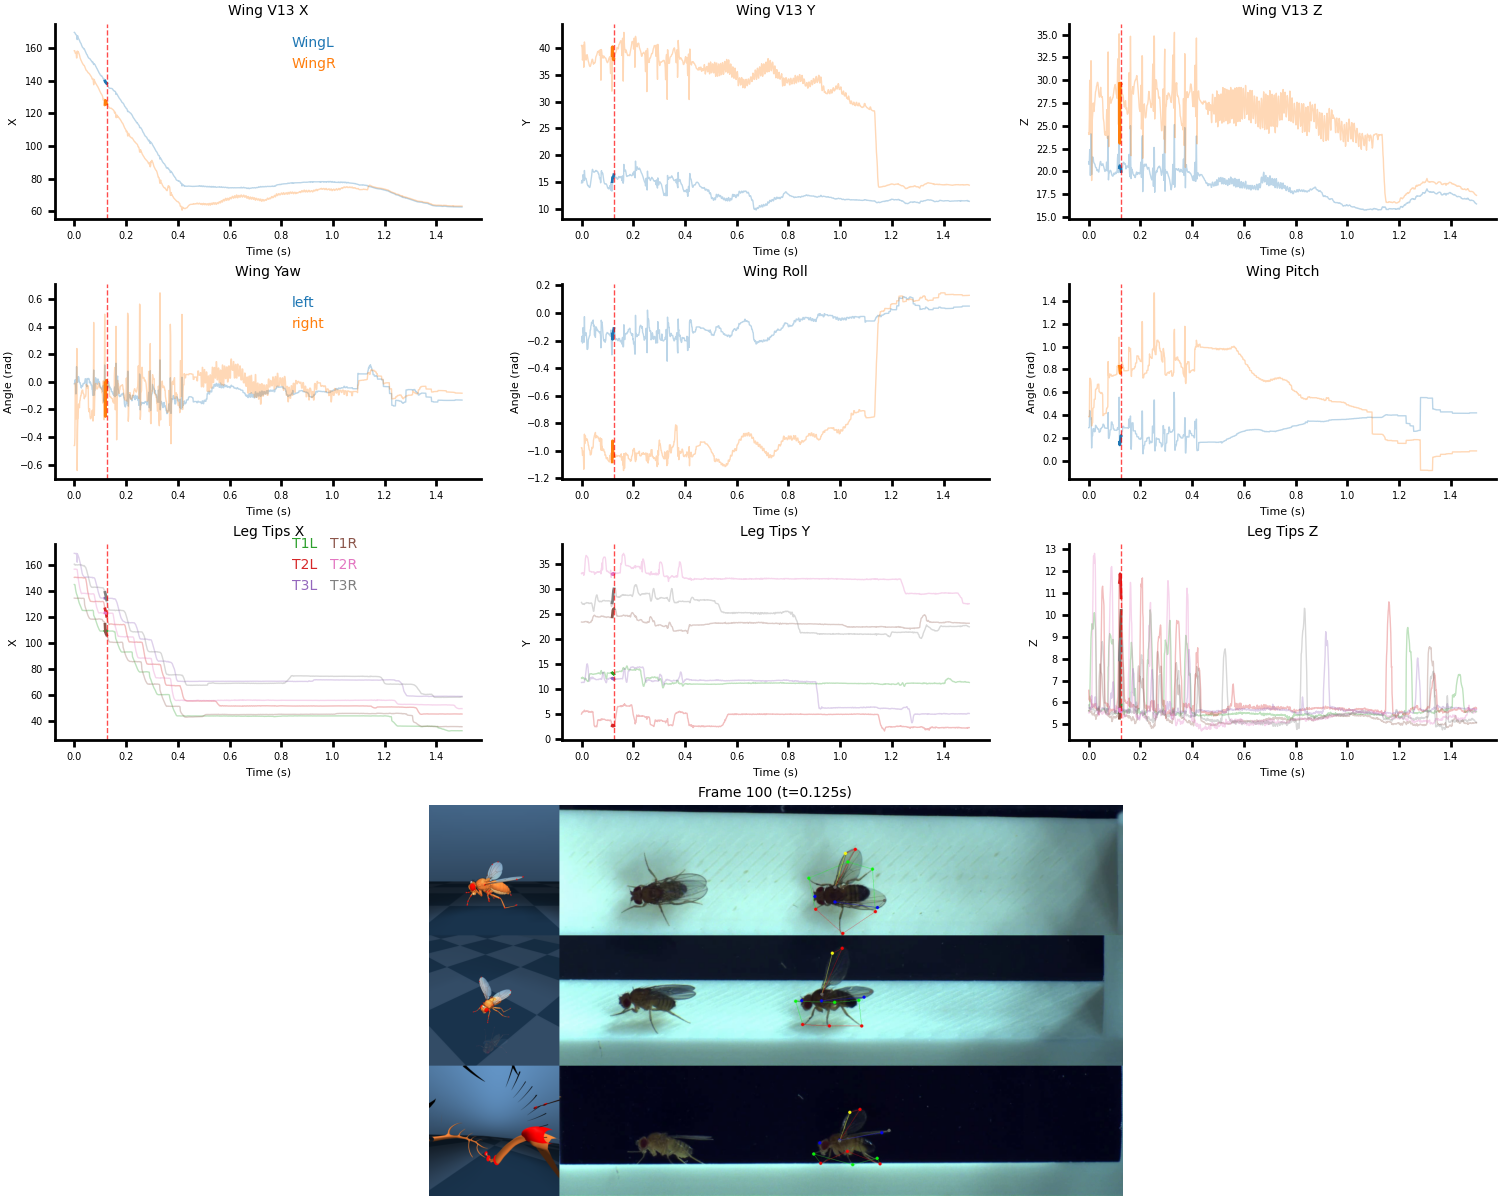

In [170]:
config = {
    'figsize': (15, 12),
    'dpi': 100,
    'wing_indices': [3, 6],
    'leg_indices': [7, 8, 9, 10, 11, 12],
    'wing_joint_indices_left': [7, 8, 9],
    'wing_joint_indices_right': [10, 11, 12],
    'wing_joint_names': d.names_qpos[7:13],
    'coord_names': ['x', 'y', 'z'],
    'trail': 5
}
im = render_frame(100, combined_vid, kp_data, mocap_qpos, time, config)
media.show_image(im)

In [173]:
# Example: Render animation with video frame and coordinate plots using Ray

# Initialize Ray (if not already initialized)
if not ray.is_initialized():
    ray.init()

# Configuration
config = {
    'figsize': (15, 12),
    'dpi': 100,  # Lower dpi for faster rendering, increase for higher quality
    'wing_indices': [3, 6],  # WingL_V13, WingR_V13
    'leg_indices': [7, 8, 9, 10, 11, 12],  # T1L, T2L, T3L, T1R, T2R, T3R
    'wing_joint_indices_left': [7, 8, 9],
    'wing_joint_indices_right': [10, 11, 12],
    'wing_joint_names': d.names_qpos[7:13],
    'coord_names': ['x', 'y', 'z'],
    'trail': 10  # Number of frames to highlight in trail
}

# Select frames to render (example: first 100 frames)
# For full video, use: frames_to_render = None
frames_to_render = list(range(0, min(1200, len(video))))

# Render frames in parallel using Ray
rendered_frames = render_animation_ray(
    vid=combined_vid,
    kp_data=np.asarray(kp_data),
    mocap_qpos=np.asarray(mocap_qpos),
    time=np.asarray(time),
    config=config,
    frames_to_render=frames_to_render
)

# Create video
# output_path = 'wing_leg_animation.mp4'
# create_video(rendered_frames, output_path, fps=30)

# Display the video (optional)
# media.show_video(rendered_frames, fps=30)

Rendering 1200 frames using Ray...
Video shape: (1200, 1344, 2384, 3), Keypoint shape: (1200, 13, 3), MoCap shape: (1200, 93)


Rendering frames:   0%|          | 0/1200 [00:00<?, ?it/s]

Rendering completed in 42.29s (28.4 fps)


In [ ]:
matplotlib.use('inline')
fps = 800
time = jnp.arange(kp_data.shape[0]) / fps

wing_jonit_names = [d.names_qpos[7:10],d.names_qpos[10:13]]
wingL_idxs = [7, 8, 9]
wingR_idxs = [10, 11, 12]
fig, axs = plt.subplots(3, 3, figsize=(12, 9))
# axs = axs.flatten()
coords = ['x', 'y', 'z']
for n, ax in enumerate(axs[0]):
    coord = coords[n]
    for side in ['L', 'R']:
        ax.plot(time,df[f'Wing{side}_V13_{coord}'].values, label=f'Wing{side}')
        ax.set_title(f'Wing_V13 {coord.upper()}')
        ax.set_xlabel('Time (s)')
axs[0,0].legend(frameon=False, loc='upper left', bbox_to_anchor=(0.5, 1.), labelcolor='linecolor',handlelength=0,handleheight=0,ncols=1,columnspacing=.1)

for side, names in zip([wingL_idxs, wingR_idxs], wing_jonit_names):
    for n, ax in enumerate(axs[1]):
        print(side[n],names[n])
        side_str = names[n].split('_')[-1]
        ax.plot(time,mocap_qpos[:,side[n]], label = f'{side_str}')
        ax.set_title(f'{names[n].split('_')[:-1]}')
        ax.set_xlabel('Time (s)')
axs[1,0].legend(frameon=False, loc='upper left', bbox_to_anchor=(0.5, 1.), labelcolor='linecolor',handlelength=0,handleheight=0,ncols=1,columnspacing=.1)

for n, ax in enumerate(axs[2]):
    coord = coords[n]
    for side in ['L', 'R']:
        ax.plot(time,df[f'T1{side}_Tip_{coord}'].values, label = f'T1{side}_Tip')
        ax.plot(time,df[f'T2{side}_Tip_{coord}'].values, label = f'T2{side}_Tip')
        ax.plot(time,df[f'T3{side}_Tip_{coord}'].values, label = f'T3{side}_Tip')
        ax.set_xlabel('Time (s)')
axs[2,0].legend(frameon=False, loc='upper left', bbox_to_anchor=(0.5, 1.), labelcolor='linecolor',handlelength=0,handleheight=0,ncols=1,columnspacing=.1)
plt.tight_layout()
plt.show()

In [175]:
media.show_video(rendered_frames, fps=60)

This browser does not support the video tag.
